## Часть 1

### 1. Загрузка исторических данных и их предобработка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
# 1. Знакомство с данными
hist_df = pd.read_csv(ХХХ, parse_dates=['first_ts', 'first_dt', 'event_ts'])

# 1.1. Изучение данных
print("1. Размер датасета:")
print(f"   - Количество строк: {hist_df.shape[0]:,}")
print(f"   - Количество столбцов: {hist_df.shape[1]}\n")

print("2. Структура данных:")
print(hist_df.info())

print("\n3. Статистика по числовым столбцам:")
print(hist_df.describe())

print("\n4. Пропущенные значения:")
print(hist_df.isnull().sum())

print("\n5. Уникальные значения в столбцах:")
categorical_cols = ['country_code', 'platform', 'event_name', 'asset', 'risk_level']
for col in categorical_cols:
    if col in hist_df.columns:
        print(f"\n{col}:")
        print(f"   - Уникальных значений: {hist_df[col].nunique()}")
        print(f"   - Значения: {hist_df[col].unique()[:10]}")

1. Размер датасета:
   - Количество строк: 238,059
   - Количество столбцов: 10

2. Структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB
None

3. Статистика по числовым столбцам:
             amount
count  33093.000000
mean     113.527967
s

In [3]:
# 1.2. Проверка дубликатов
duplicates = hist_df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")

# 1.3. Проверка формата дат
print(f"Диапазон first_dt: {hist_df['first_dt'].min()} - {hist_df['first_dt'].max()}")
print(f"Диапазон first_ts: {hist_df['first_ts'].min()} - {hist_df['first_ts'].max()}")
print(f"Диапазон event_ts: {hist_df['event_ts'].min()} - {hist_df['event_ts'].max()}")

Полных дубликатов строк: 0
Диапазон first_dt: 2025-04-01 00:00:00 - 2025-06-01 00:00:00
Диапазон first_ts: 2025-04-01 00:06:34 - 2025-06-01 23:59:52
Диапазон event_ts: 2025-04-01 00:06:34 - 2025-06-09 20:24:42


In [4]:
# 2.Предобработка данных

# 2.1. Проверка на корректность данных
# Проверка отрицательных сумм депозита
negative_amounts = hist_df[hist_df['amount'] < 0]['amount'].count()
print(f"1. Отрицательные суммы депозита: {negative_amounts}")

# Проверка корректности дат
invalid_dates = hist_df[hist_df['first_ts'] > hist_df['event_ts']].shape[0]
print(f"2. Записи с event_ts раньше first_ts: {invalid_dates}")

# Проверка платформы
print(f"3. Значения platform: {hist_df['platform'].unique()}")
print(f"4. Значения risk_level: {hist_df['risk_level'].unique()}")
print(f"5. Значения event_name: {hist_df['event_name'].unique()}")


1. Отрицательные суммы депозита: 0
2. Записи с event_ts раньше first_ts: 0
3. Значения platform: ['mobile' 'web']
4. Значения risk_level: [nan 'medium' 'high' 'low']
5. Значения event_name: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']


In [5]:
# 3.1. Количество уникальных пользователей
unique_users = hist_df['user_id'].nunique()
print(f"Уникальных пользователей: {unique_users:,}")

# 3.2. Распределение по странам
print("\nРаспределение по странам:")
country_dist = hist_df.groupby('country_code')['user_id'].nunique().sort_values(ascending=False)
print(country_dist.head())

print("\nРаспределение по платформам:")
platform_dist = hist_df.groupby('platform')['user_id'].nunique()
print(platform_dist)

# 3.3. Распределение событий
print("\nРаспределение событий:")
event_dist = hist_df['event_name'].value_counts()
print(event_dist)

# 3.4. Анализ депозитов
print("\nАнализ депозитов:")
deposits = hist_df[hist_df['event_name'] == 'first_deposit']
if len(deposits) > 0:
    print(f"Всего депозитов: {len(deposits):,}")
    print(f"Уникальных пользователей с депозитами: {deposits['user_id'].nunique():,}")
    print(f"Средняя сумма депозита: {deposits['amount'].mean():.2f}")
    print(f"Медианная сумма депозита: {deposits['amount'].median():.2f}")
    print(f"Максимальная сумма депозита: {deposits['amount'].max():.2f}")

Уникальных пользователей: 41,032

Распределение по странам:
country_code
BR    12266
MX    11303
CO     9974
AR     7489
Name: user_id, dtype: int64

Распределение по платформам:
platform
mobile    28758
web       12274
Name: user_id, dtype: int64

Распределение событий:
install / open_web     41032
introduction           41032
registration           38133
main_page              35040
onboarding_complete    34337
first_deposit          27685
asset_purchase         15392
second_deposit          5408
Name: event_name, dtype: int64

Анализ депозитов:
Всего депозитов: 27,685
Уникальных пользователей с депозитами: 27,685
Средняя сумма депозита: 112.54
Медианная сумма депозита: 109.00
Максимальная сумма депозита: 315.00


**Промежуточные выводы**
1. Основная информация о данных:
    - Размер датасета: 238,059 запись, 10 столбцов
    - Период данных: 1 апреля - 1 июня 2025 года
    - Количество уникальных пользователей: 41,032
2. Структура данных:
    - Числовые столбцы: amount (сумма депозита)
    - Категориальные: country_code, platform, event_name, asset, risk_level
    - Временные: first_dt, first_ts, event_ts

3. Выявленные особенности:
    - Пропуски: amount, asset, risk_level имеют пропуски, что логично, так как эти поля заполняются только при открытии депозита
    - Типы данных: даты требовали изменения типа данных
    - Дубликаты: отсутствуют
    
4. Проведенная предобработка:
    - Конвертированы временные поля в datetime формат
    - Проверена корректность данных: нет отрицательных сумм

5. Ключевые метрики:
    - Распределение по странам: преобладают BR (Бразилия), MX (Мексика), AR (Аргентина), CO (Колумбия)
    - Платформы: mobile и web (преоблажают пользователи мобильных)
    - Депозиты: 27,685 пользователей совершили депозиты

In [6]:
# Финальный датасет
display(hist_df)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
238054,aa03675f-77da-4f85-a2e4-0776daa7b7f2,CO,mobile,2025-04-26 22:30:32,2025-04-26,2025-04-29 04:32:47,first_deposit,75.0,NaN,NaN
238055,aa03675f-77da-4f85-a2e4-0776daa7b7f2,CO,mobile,2025-04-26 22:30:32,2025-04-26,2025-04-30 13:59:02,asset_purchase,NaN,crypto,high
238056,aa03675f-77da-4f85-a2e4-0776daa7b7f2,CO,mobile,2025-04-26 22:30:32,2025-04-26,2025-05-03 04:28:59,second_deposit,117.0,NaN,NaN
238057,4e5a1c6d-79c5-4a81-8477-e1cb8bc3b33d,MX,mobile,2025-04-09 10:02:20,2025-04-09,2025-04-09 10:02:20,install / open_web,NaN,NaN,NaN


---

### 2. Исследовательский анализ исторических данных

**Задача 2.1.** Анализ новых пользователей.
- Динамика привлечения новых пользователей в приложение.

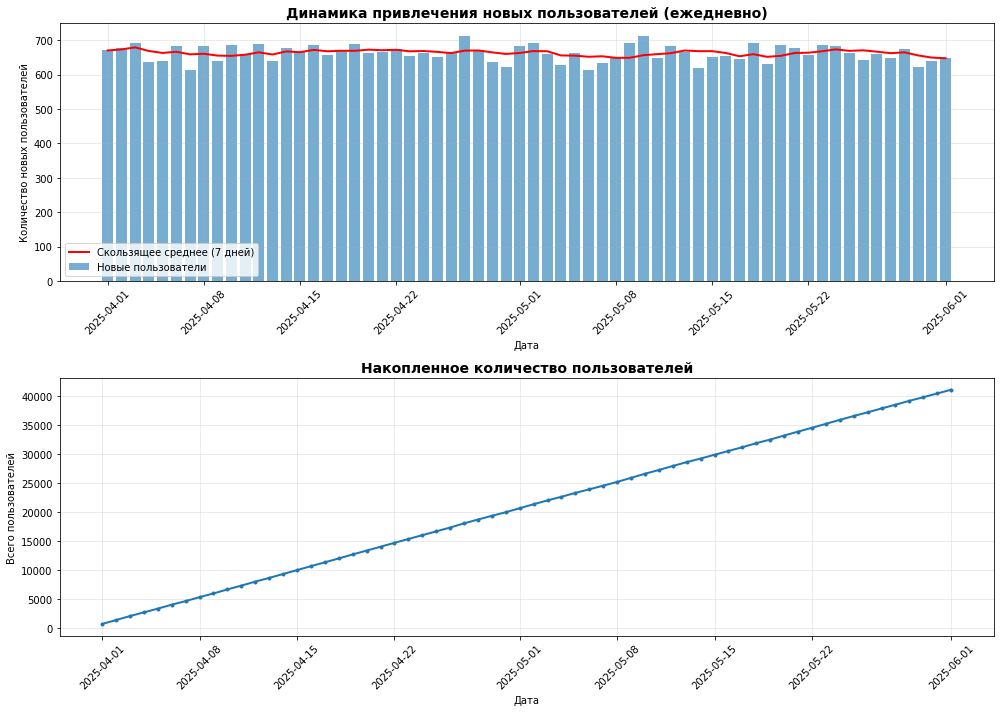

In [7]:
# Уникальных пользователей по дате первого появления
new_users_daily = hist_df.groupby('first_dt')['user_id'].nunique().reset_index()
new_users_daily.columns = ['date', 'new_users']

# Скользящее среднее за 7 дней
new_users_daily['ma7'] = new_users_daily['new_users'].rolling(window=7, min_periods=1).mean()

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Ежедневное привлечение
axes[0].bar(new_users_daily['date'], new_users_daily['new_users'], alpha=0.6, label='Новые пользователи')
axes[0].plot(new_users_daily['date'], new_users_daily['ma7'], color='red', linewidth=2, label='Скользящее среднее (7 дней)')
axes[0].set_title('Динамика привлечения новых пользователей (ежедневно)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество новых пользователей')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# График 2: Накопленное количество пользователей
new_users_daily['cumulative'] = new_users_daily['new_users'].cumsum()
axes[1].plot(new_users_daily['date'], new_users_daily['cumulative'], marker='o', markersize=3, linewidth=2)
axes[1].set_title('Накопленное количество пользователей', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Всего пользователей')
axes[1].grid(True, alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Статистика
print("Статистика привлечения новых пользователей:")
print(f"Всего привлечено пользователей: {new_users_daily['new_users'].sum():,}")
print(f"Среднее количество в день: {new_users_daily['new_users'].mean():.0f}")
print(f"Максимум в день: {new_users_daily['new_users'].max():,} ({new_users_daily.loc[new_users_daily['new_users'].idxmax(), 'date'].strftime('%Y-%m-%d')})")
print(f"Минимум в день: {new_users_daily['new_users'].min():,} ({new_users_daily.loc[new_users_daily['new_users'].idxmin(), 'date'].strftime('%Y-%m-%d')})")

Статистика привлечения новых пользователей:
Всего привлечено пользователей: 41,032
Среднее количество в день: 662
Максимум в день: 713 (2025-04-27)
Минимум в день: 613 (2025-05-06)


**Промежуточные выводы**
1. Приложение стабильно привлекает пользователей в диапазоне от 613 до 713 новых пользователей. 
2. Всего было привлечено с 1 апреля по 1 июня 41,032 новых пользователей

**Задача 2.2.** Анализ воронок событий.
- Постройте классическую и пошаговую воронки;
- Охарактеризуйте пользовательский путь в приложении и определите узкие места воронки. 


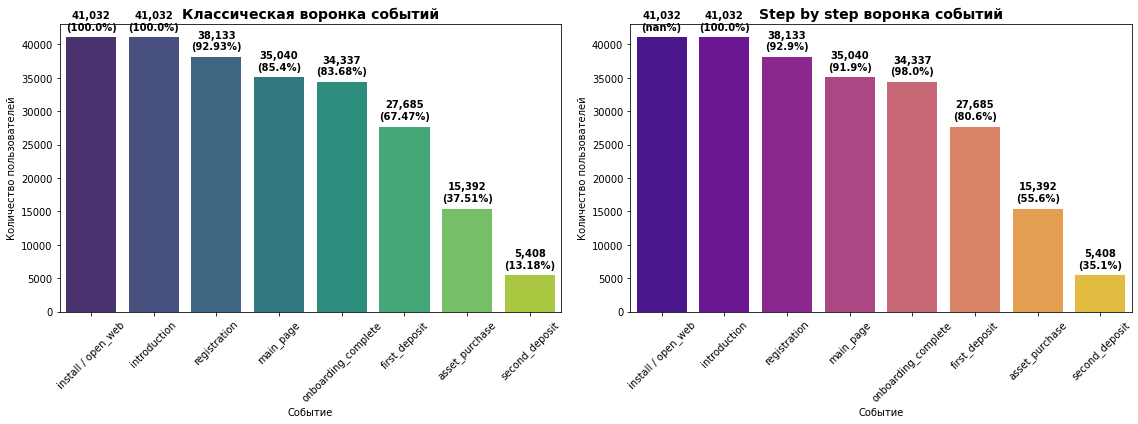

In [14]:
# 1. Классическая воронка
event_1 = ['install / open_web', 'introduction', 'registration', 'main_page', 
               'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

# Рассчитываем количество уникальных пользователей на каждом этапе
funnel_classic = {}
for event in event_1:
    users_at_event = hist_df[hist_df['event_name'] == event]['user_id'].nunique()
    funnel_classic[event] = users_at_event

funnel_classic_df = pd.DataFrame(list(funnel_classic.items()), columns=['event', 'users'])
funnel_classic_df['conversion_from_start'] = (funnel_classic_df['users'] / funnel_classic_df['users'].iloc[0] * 100).round(2)

# 2. Step by step воронка
funnel_seq_users = []
for event in event_1:
    users_at_event = hist_df[hist_df['event_name'] == event]['user_id'].nunique()
    funnel_seq_users.append(users_at_event)

funnel_seq_df = pd.DataFrame({'event': event_1, 'users': funnel_seq_users})
funnel_seq_df['conversion_from_prev'] = (funnel_seq_df['users'] / funnel_seq_df['users'].shift(1) * 100).round(2)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Классическая воронка
sns.barplot(data=funnel_classic_df, x='event', y='users', ax=axes[0], palette='viridis')
axes[0].set_title('Классическая воронка событий', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Событие')
axes[0].set_ylabel('Количество пользователей')
axes[0].tick_params(axis='x', rotation=45)

for i, (event, users, conv) in enumerate(zip(funnel_classic_df['event'], 
                                             funnel_classic_df['users'], 
                                             funnel_classic_df['conversion_from_start'])):
    axes[0].text(i, users + (funnel_classic_df['users'].max() * 0.02), 
                 f'{users:,}\n({conv}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Step by step воронка
sns.barplot(data=funnel_seq_df, x='event', y='users', ax=axes[1], palette='plasma')
axes[1].set_title('Step by step воронка событий', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Событие')
axes[1].set_ylabel('Количество пользователей')
axes[1].tick_params(axis='x', rotation=45)

for i, (event, users, conv) in enumerate(zip(funnel_seq_df['event'], 
                                             funnel_seq_df['users'], 
                                             funnel_seq_df['conversion_from_prev'])):
    axes[1].text(i, users + (funnel_seq_df['users'].max() * 0.02), 
                     f'{users:,}\n({conv:.1f}%)', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.tight_layout()
plt.show()

In [15]:
print("Классическая воронка:")
print(funnel_classic_df)
print("\nStep by step воронка:")
print(funnel_seq_df)

Классическая воронка:
                 event  users  conversion_from_start
0   install / open_web  41032                 100.00
1         introduction  41032                 100.00
2         registration  38133                  92.93
3            main_page  35040                  85.40
4  onboarding_complete  34337                  83.68
5        first_deposit  27685                  67.47
6       asset_purchase  15392                  37.51
7       second_deposit   5408                  13.18

Step by step воронка:
                 event  users  conversion_from_prev
0   install / open_web  41032                   NaN
1         introduction  41032                100.00
2         registration  38133                 92.93
3            main_page  35040                 91.89
4  onboarding_complete  34337                 97.99
5        first_deposit  27685                 80.63
6       asset_purchase  15392                 55.60
7       second_deposit   5408                 35.14


**Промежуточные выводы по воронкам:**

1. **Классическая воронка**: Конверсия из установки в регистрацию составляет 93% (38,133 / 41,032), что является хорошим показателем. Однако ключевое падение происходит на этапе перехода к финансовой активности: только 67.5% зарегистрировавшихся пользователей открывают первый депозит (27,685 / 41,032 от установки). Еще более существенное падение наблюдается при переходе ко второму депозиту: только 13.2% пользователей от установки (5,408 / 41,032) совершают повторный депозит.
2. **Последовательная воронка**: Самые большие потери конверсии (узкие места):
    - От первого депозита ко второму: Конверсия составляет всего 35.1% (5,408 / 15,392)
3. **Вывод**: Анализ пользовательского пути подтверждает гипотезу бизнеса о том, что пользователи, возможно, не понимают инвестиционные риски, что приводит к быстрому оттоку после первоначального вложения.

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита.
- Как уровень риска первого актива влияет на конверсию во второй депозит.  

In [16]:
# 1. Данные о первом купленном активе для каждого пользователя
first_asset = hist_df[hist_df['event_name'] == 'asset_purchase'].sort_values('event_ts').groupby('user_id').first().reset_index()
first_asset = first_asset[['user_id', 'risk_level', 'asset']]

# 2. Данные о втором депозите
second_deposit_users = hist_df[hist_df['event_name'] == 'second_deposit']['user_id'].unique()

# 3. Объединяем и считаем конверсию
conversion_risk = first_asset.copy()
conversion_risk['second_deposit'] = conversion_risk['user_id'].isin(second_deposit_users)

# 4. Группируем по уровню риска
risk_conversion = conversion_risk.groupby('risk_level').agg(
    users=('user_id', 'count'),
    second_deposit=('second_deposit', 'sum')
).reset_index()
risk_conversion['conversion_rate'] = (risk_conversion['second_deposit'] / risk_conversion['users'] * 100).round(2)

print("Влияние уровня риска первого актива на конверсию во второй депозит:")
print(risk_conversion)

Влияние уровня риска первого актива на конверсию во второй депозит:
  risk_level  users  second_deposit  conversion_rate
0       high   7740            2040            26.36
1        low   2327            1080            46.41
2     medium   5325            2288            42.97


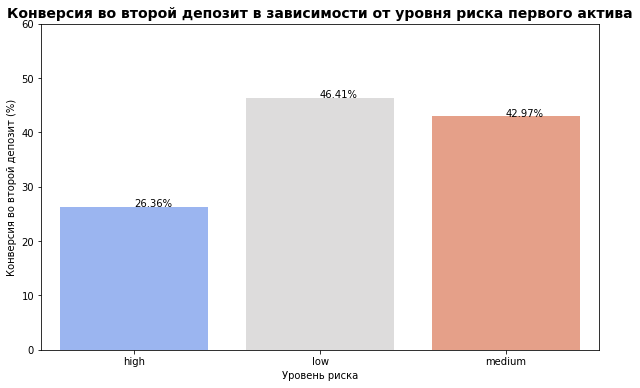

In [17]:
# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=risk_conversion, x='risk_level', y='conversion_rate', palette='coolwarm')
plt.title('Конверсия во второй депозит в зависимости от уровня риска первого актива', fontsize=14, fontweight='bold')
plt.xlabel('Уровень риска')
plt.ylabel('Конверсия во второй депозит (%)')
plt.ylim(0, 60)
for index, row in risk_conversion.iterrows():
    plt.text(index, row['conversion_rate'], f"{row['conversion_rate']}%")
plt.show()

**Промежуточные выводы:**
1. **Наблюдения**:
- Пользователи, которые купили актив с высоким уровнем риска, имеют самую низкую конверсию во второй депозит (26.3%).
- Пользователи, которые купили актив со средним уровнем риска, имеют более высокую конверсию (42.3%).
- Пользователи, которые купили актив с низким уровнем риска, имеют самую высокую конверсию (46.4%).

2. **Вывод**: Наблюдается четкая корреляция между уровнем риска первого приобретенного актива и вероятностью повторного депозита. Чем выше риск, тем ниже конверсия. Это подтверждает дополнительную гипотезу о том, что пользователи, покупающие высокорискованные активы, вероятно, не полностью осознают риски и теряют деньги, что приводит к оттоку.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.

Ключевая метрика: 91.56


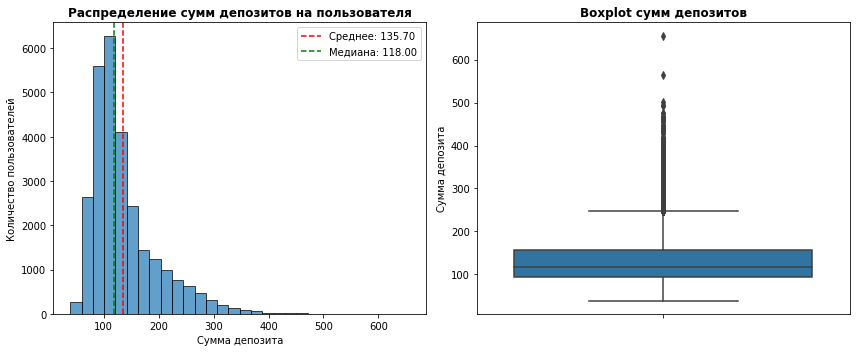


Статистика по депозитам платящих пользователей:
Средняя сумма: 135.70
Медианная сумма: 118.00
Стандартное отклонение: 59.90
25-й перцентиль: 95.00
75-й перцентиль: 156.00


In [18]:
# 1. Общая сумма депозитов на пользователя
user_deposits = hist_df[hist_df['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum().reset_index()
user_deposits.columns = ['user_id', 'total_deposit']

# 2. Объединяем со всеми пользователями
all_users = pd.DataFrame({'user_id': hist_df['user_id'].unique()})
all_users = all_users.merge(user_deposits, on='user_id', how='left').fillna(0)

# 3. Ключевая метрика
key_metric_hist = all_users['total_deposit'].mean()
print(f"Ключевая метрика: {key_metric_hist:.2f}")

# 4. Визуализация 
plt.figure(figsize=(12, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(user_deposits['total_deposit'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение сумм депозитов на пользователя', fontsize=12, fontweight='bold')
plt.xlabel('Сумма депозита')
plt.ylabel('Количество пользователей')
plt.axvline(user_deposits['total_deposit'].mean(), color='red', linestyle='--', label=f'Среднее: {user_deposits["total_deposit"].mean():.2f}')
plt.axvline(user_deposits['total_deposit'].median(), color='green', linestyle='--', label=f'Медиана: {user_deposits["total_deposit"].median():.2f}')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=user_deposits['total_deposit'])
plt.title('Boxplot сумм депозитов', fontsize=12, fontweight='bold')
plt.ylabel('Сумма депозита')

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика по депозитам платящих пользователей:")
print(f"Средняя сумма: {user_deposits['total_deposit'].mean():.2f}")
print(f"Медианная сумма: {user_deposits['total_deposit'].median():.2f}")
print(f"Стандартное отклонение: {user_deposits['total_deposit'].std():.2f}")
print(f"25-й перцентиль: {user_deposits['total_deposit'].quantile(0.25):.2f}")
print(f"75-й перцентиль: {user_deposits['total_deposit'].quantile(0.75):.2f}")

**Промежуточные выводы**:

1. Ключевая метрика: Средняя сумма всех депозитов на одного пользователя (включая неплатящих) составляет 91.56.

2. Распределение сумм: Распределение имеет правостороннюю асимметрию (среднее (135.7) > медианы (118) для платящих пользователей). Это означает, что большинство пользователей вносят суммы, близкие к медиане, но есть небольшая группа пользователей с более крупными депозитами, которые "тянут" среднее значение вверх.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента


In [19]:
# 1. Знакомство с данными
df = pd.read_csv('ХХХ', parse_dates=['first_ts', 'first_dt', 'event_ts'])
# 1. Знакомство с данными

# 1.1. Изучение данных
print("1. Размер датасета:")
print(f"   - Количество строк: {df.shape[0]:,}")
print(f"   - Количество столбцов: {df.shape[1]}\n")

print("2. Структура данных:")
print(df.info())

print("\n3. Статистика по числовым столбцам:")
print(df.describe())

print("\n4. Пропущенные значения:")
print(df.isnull().sum())

print("\n5. Уникальные значения в столбцах:")
categorical_cols = ['country_code', 'platform', 'event_name', 'asset', 'risk_level']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"   - Уникальных значений: {hist_df[col].nunique()}")
        print(f"   - Значения: {hist_df[col].unique()[:10]}")

1. Размер датасета:
   - Количество строк: 54,805
   - Количество столбцов: 12

2. Структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB
None

3. Статистика

In [20]:
# 1.2. Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")

# 1.3. Проверка формата дат
print(f"Диапазон first_dt: {df['first_dt'].min()} - {df['first_dt'].max()}")
print(f"Диапазон first_ts: {df['first_ts'].min()} - {df['first_ts'].max()}")
print(f"Диапазон event_ts: {df['event_ts'].min()} - {df['event_ts'].max()}")

Полных дубликатов строк: 0
Диапазон first_dt: 2025-06-02 00:00:00 - 2025-06-15 00:00:00
Диапазон first_ts: 2025-06-02 00:27:50 - 2025-06-15 23:58:39
Диапазон event_ts: 2025-06-02 00:27:50 - 2025-06-22 13:37:05


In [21]:
# 2.Предобработка данных

# 2.1. Конвертация дат в datetime формат
df['first_dt'] = pd.to_datetime(df['first_dt'])
df['first_ts'] = pd.to_datetime(df['first_ts'])
df['event_ts'] = pd.to_datetime(df['event_ts'])

# 2.2. Проверка на корректность данных
# Проверка отрицательных сумм депозита
negative_amounts = df[df['amount'] < 0]['amount'].count()
print(f"1. Отрицательные суммы депозита: {negative_amounts}")

# Проверка корректности дат
invalid_dates = df[df['first_ts'] > df['event_ts']].shape[0]
print(f"2. Записи с event_ts раньше first_ts: {invalid_dates}")

# Проверка платформы
print(f"3. Значения platform: {df['platform'].unique()}")
print(f"4. Значения risk_level: {df['risk_level'].unique()}")
print(f"5. Значения event_name: {df['event_name'].unique()}")


1. Отрицательные суммы депозита: 0
2. Записи с event_ts раньше first_ts: 0
3. Значения platform: ['mobile' 'web']
4. Значения risk_level: [nan 'high' 'low' 'medium']
5. Значения event_name: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']


In [22]:
# 3.1. Количество уникальных пользователей
unique_users = df['user_id'].nunique()
print(f"Уникальных пользователей: {unique_users:,}")

# 3.2. Распределение по странам
print("\nРаспределение по странам:")
country_dist = df.groupby('country_code')['user_id'].nunique().sort_values(ascending=False)
print(country_dist.head())

print("\nРаспределение по платформам:")
platform_dist = df.groupby('platform')['user_id'].nunique()
print(platform_dist)

# 3.3. Распределение событий
print("\nРаспределение событий:")
event_dist = df['event_name'].value_counts()
print(event_dist)

# 3.4. Анализ депозитов
print("\nАнализ депозитов:")
deposits = df[df['event_name'] == 'first_deposit']
if len(deposits) > 0:
    print(f"Всего депозитов: {len(deposits):,}")
    print(f"Уникальных пользователей с депозитами: {deposits['user_id'].nunique():,}")
    print(f"Средняя сумма депозита: {deposits['amount'].mean():.2f}")
    print(f"Медианная сумма депозита: {deposits['amount'].median():.2f}")
    print(f"Максимальная сумма депозита: {deposits['amount'].max():.2f}")

Уникальных пользователей: 9,415

Распределение по странам:
country_code
BR    2991
MX    2497
CO    2446
AR    1481
Name: user_id, dtype: int64

Распределение по платформам:
platform
mobile    6631
web       2784
Name: user_id, dtype: int64

Распределение событий:
install / open_web     9415
introduction           9415
registration           8777
main_page              8080
onboarding_complete    7525
first_deposit          6215
asset_purchase         3750
second_deposit         1628
Name: event_name, dtype: int64

Анализ депозитов:
Всего депозитов: 6,215
Уникальных пользователей с депозитами: 6,215
Средняя сумма депозита: 105.63
Медианная сумма депозита: 98.00
Максимальная сумма депозита: 650.00


In [23]:
# Финальный датасет
display(df)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
54800,e3e7417d-6402-4971-a30d-47aba10de59e,CO,web,2025-06-12 13:03:15,2025-06-12,2025-06-19 01:36:37,second_deposit,onboarding_test,control,128.0,NaN,NaN
54801,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 12:20:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
54802,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 12:20:52,introduction,onboarding_test,test,NaN,NaN,NaN
54803,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 18:46:57,registration,onboarding_test,test,NaN,NaN,NaN


**Задача 3.1.** Анализ аудитории эксперимента. 
- Проверьте корректность распределения новых пользователей по группам А/В-эксперимента. 
- Постройте графики и сформулируйте промежуточный вывод. 

Распределение пользователей по группам:
group
control    4847
test       4568
Name: user_id, dtype: int64
Разница в количестве пользователей: 279

Распределение по странам в группах:
country_code   AR    BR    CO    MX
group                              
control       756  1543  1247  1301
test          725  1448  1199  1196

Распределение по платформам в группах:
platform  mobile   web
group                 
control     3385  1462
test        3246  1322


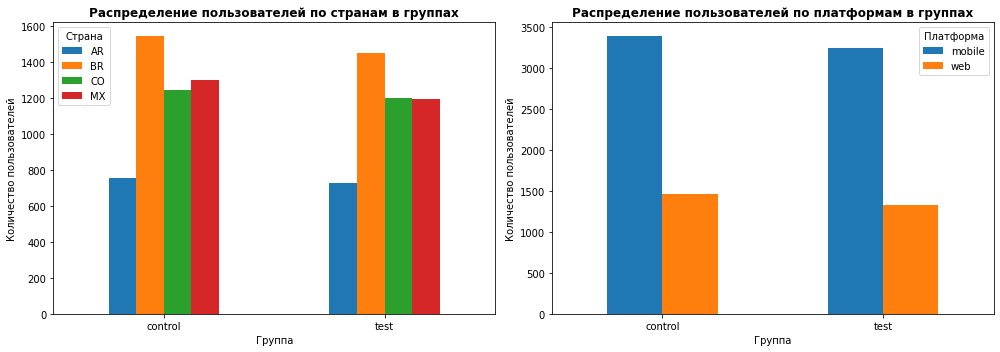

In [33]:
# 1. Проверка распределения по группам
print("Распределение пользователей по группам:")
group_counts = df.groupby('group')['user_id'].nunique()
print(group_counts)
print(f"Разница в количестве пользователей: {abs(group_counts['control'] - group_counts['test'])}")

# 2. Проверка распределения по странам и платформам
print("\nРаспределение по странам в группах:")
country_group = df.groupby(['group', 'country_code'])['user_id'].nunique().unstack()
print(country_group)

print("\nРаспределение по платформам в группах:")
platform_group = df.groupby(['group', 'platform'])['user_id'].nunique().unstack()
print(platform_group)

# 3. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_group.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Распределение пользователей по странам в группах', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Группа')
axes[0].set_ylabel('Количество пользователей')
axes[0].legend(title='Страна')

platform_group.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Распределение пользователей по платформам в группах', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Количество пользователей')
axes[1].legend(title='Платформа')

plt.tight_layout()
plt.show()

**Промежуточные выводы по аудитории:**

- Распределение по группам: Контрольная группа (4,847) и тестовая группа (4,568) имеют незначительную разницу в размере (279 пользователей). Это допустимо для случайного распределения.

- Распределение по странам и платформам: Распределение пользователей по странам (BR, MX, CO, AR) и платформам (mobile, web) визуально однородно между группами. Это говорит о корректности рандомизации и о том, что группы сопоставимы

In [34]:
# 4. Проверка на пересечение пользователей между группами
control_users = set(df[df['group'] == 'control']['user_id'].unique())
test_users = set(df[df['group'] == 'test']['user_id'].unique())

intersection = control_users.intersection(test_users)

if len(intersection) > 0:
    print(f"Найдено {len(intersection)} пользователей, которые присутствуют в обеих группах!")
else:
    print("Пересечение пользователей между группами отсутствует. Группы независимы.")

Пересечение пользователей между группами отсутствует. Группы независимы.


**Задача 3.2.** Сравнение воронок событий.

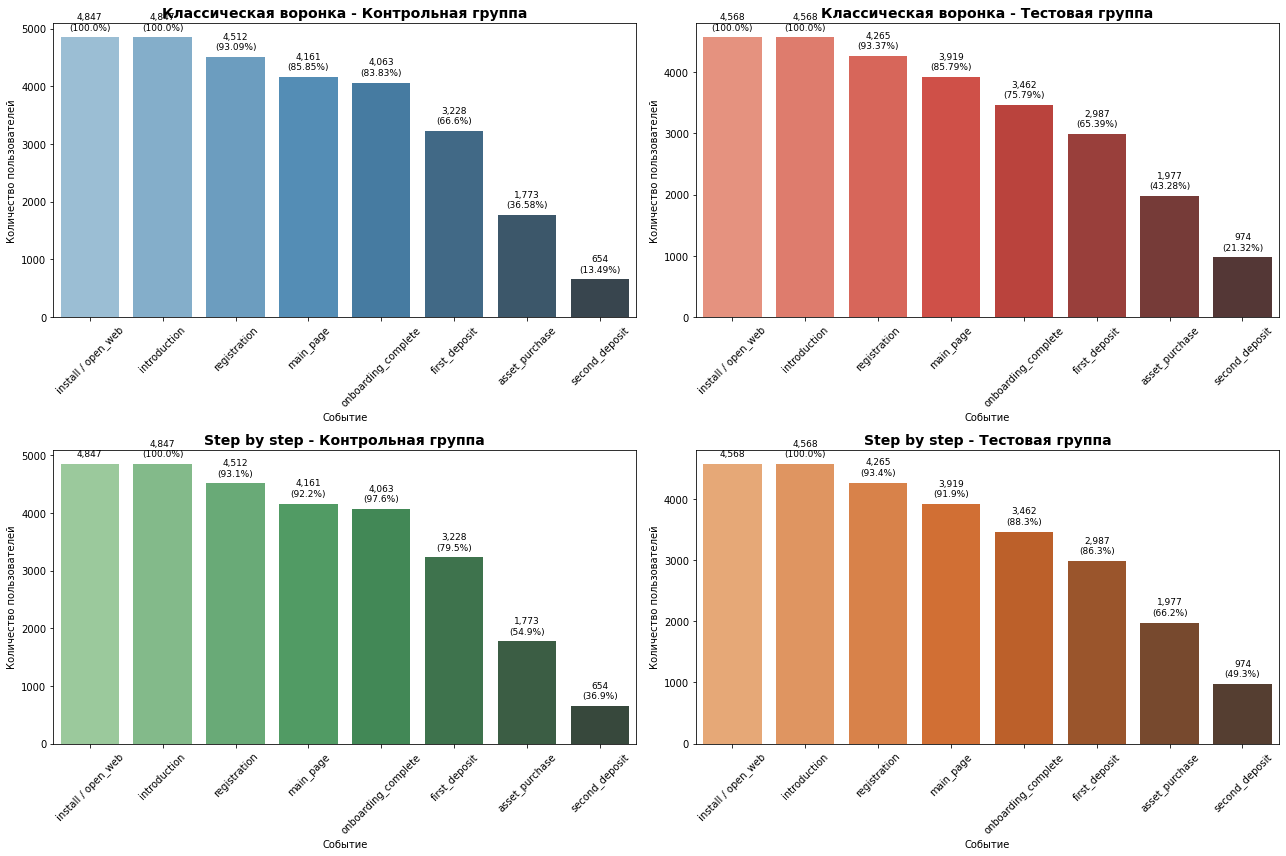

In [40]:
# Функция для построения воронки для группы
def build_funnel(data, group_name):
    event_order = ['install / open_web', 'introduction', 'registration', 'main_page', 
                   'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']
    
    funnel = {}
    for event in event_order:
        users_at_event = data[data['event_name'] == event]['user_id'].nunique()
        funnel[event] = users_at_event
    
    funnel_df = pd.DataFrame(list(funnel.items()), columns=['event', 'users'])
    funnel_df['conversion_from_start'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(2)
    funnel_df['group'] = group_name
    
    # Последовательная конверсия
    funnel_df['conversion_from_prev'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(2)
    
    return funnel_df

# Строим воронки для каждой группы
control_funnel = build_funnel(df[df['group'] == 'control'], 'Контрольная группа')
test_funnel = build_funnel(df[df['group'] == 'test'], 'Тестовая группа')

# Визуализация 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Классическая воронка - контрольная группа
sns.barplot(data=control_funnel, x='event', y='users', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Классическая воронка - Контрольная группа', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Событие')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].tick_params(axis='x', rotation=45)

# Добавляем подписи на столбцы
for i, (event, users, conv) in enumerate(zip(control_funnel['event'], 
                                             control_funnel['users'], 
                                             control_funnel['conversion_from_start'])):
    axes[0, 0].text(i, users + (control_funnel['users'].max() * 0.02), 
                    f'{users:,}\n({conv}%)', 
                    ha='center', va='bottom', fontsize=9)

# 2. Классическая воронка - тестовая группа
sns.barplot(data=test_funnel, x='event', y='users', ax=axes[0, 1], palette='Reds_d')
axes[0, 1].set_title('Классическая воронка - Тестовая группа', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Событие')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=45)

# Добавляем подписи на столбцы
for i, (event, users, conv) in enumerate(zip(test_funnel['event'], 
                                             test_funnel['users'], 
                                             test_funnel['conversion_from_start'])):
    axes[0, 1].text(i, users + (test_funnel['users'].max() * 0.02), 
                    f'{users:,}\n({conv}%)', 
                    ha='center', va='bottom', fontsize=9)

# 3. Step by step - контрольная группа
sns.barplot(data=control_funnel, x='event', y='users', ax=axes[1, 0], palette='Greens_d')
axes[1, 0].set_title('Step by step - Контрольная группа', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Событие')
axes[1, 0].set_ylabel('Количество пользователей')
axes[1, 0].tick_params(axis='x', rotation=45)

# Добавляем подписи с последовательной конверсией
for i, (event, users, conv_prev) in enumerate(zip(control_funnel['event'], 
                                                   control_funnel['users'], 
                                                   control_funnel['conversion_from_prev'])):
    if not pd.isna(conv_prev):
        axes[1, 0].text(i, users + (control_funnel['users'].max() * 0.02), 
                        f'{users:,}\n({conv_prev:.1f}%)', 
                        ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 0].text(i, users + (control_funnel['users'].max() * 0.02), 
                        f'{users:,}', 
                        ha='center', va='bottom', fontsize=9)

# 4. Step by step - тестовая группа
sns.barplot(data=test_funnel, x='event', y='users', ax=axes[1, 1], palette='Oranges_d')
axes[1, 1].set_title('Step by step - Тестовая группа', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Событие')
axes[1, 1].set_ylabel('Количество пользователей')
axes[1, 1].tick_params(axis='x', rotation=45)

# Добавляем подписи с последовательной конверсией
for i, (event, users, conv_prev) in enumerate(zip(test_funnel['event'], 
                                                   test_funnel['users'], 
                                                   test_funnel['conversion_from_prev'])):
    if not pd.isna(conv_prev):
        axes[1, 1].text(i, users + (test_funnel['users'].max() * 0.02), 
                        f'{users:,}\n({conv_prev:.1f}%)', 
                        ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 1].text(i, users + (test_funnel['users'].max() * 0.02), 
                        f'{users:,}', 
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
# Ключевые метрики конверсии
key_events = ['first_deposit', 'second_deposit']
for event in key_events:
    control_conv = control_funnel[control_funnel['event'] == event]['conversion_from_start'].values[0]
    test_conv = test_funnel[test_funnel['event'] == event]['conversion_from_start'].values[0]
    diff = test_conv - control_conv
    rel_change = (test_conv / control_conv - 1) * 100 if control_conv != 0 else 0
    
    print(f"\n{event.replace('_', ' ').title()}:")
    print(f"  Контрольная группа: {control_conv:.2f}%")
    print(f"  Тестовая группа: {test_conv:.2f}%")
    print(f"  Абсолютная разница: {diff:+.2f} п.п.")
    print(f"  Относительное изменение: {rel_change:+.1f}%")


First Deposit:
  Контрольная группа: 66.60%
  Тестовая группа: 65.39%
  Абсолютная разница: -1.21 п.п.
  Относительное изменение: -1.8%

Second Deposit:
  Контрольная группа: 13.49%
  Тестовая группа: 21.32%
  Абсолютная разница: +7.83 п.п.
  Относительное изменение: +58.0%


**Промежуточные выводы по воронкам:**

1. **Конверсия в регистрацию:**
   - Контрольная группа: 93.1%
   - Тестовая группа: 93.4%
   - Разница минимальна, группы сопоставимы на начальном этапе

2. **Конверсия в первый депозит**: В тестовой группе конверсия ниже (65.39% против 66.6%). Можно предположить, что информация о рисках могла отпугнуть некоторых осторожных пользователей от первого вложения.

3. **Конверсия во второй депозит**: В тестовой группе конверсия выше (21.32% против 13.49%). Это подтверждает гипотезу роста: пользователи, прошедшие новый онбординг, лучше понимают риски и более склонны к повторным вложениям.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.

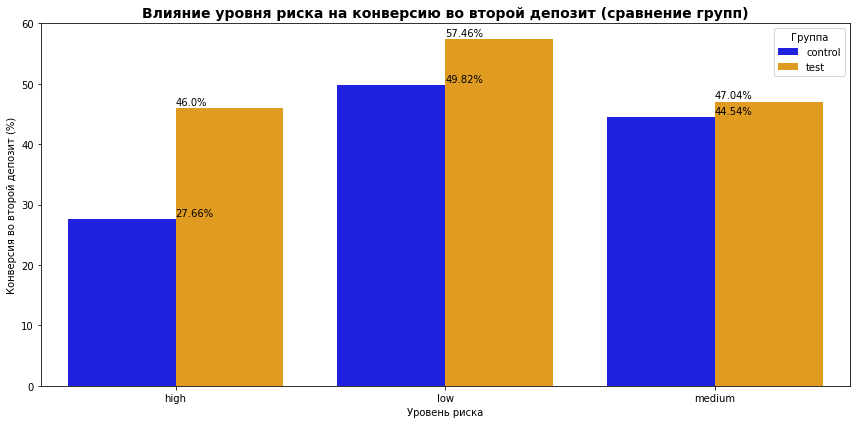

Сравнение конверсии во второй депозит по уровням риска:
group       control   test
risk_level                
high          27.66  46.00
low           49.82  57.46
medium        44.54  47.04


In [41]:
# Функция для расчета конверсии по уровням риска
def conversion_by_risk(data, group_name):
    # 1. Получаем первый купленный актив
    first_asset = data[data['event_name'] == 'asset_purchase'].sort_values('event_ts').groupby('user_id').first().reset_index()
    first_asset = first_asset[['user_id', 'risk_level']]
    
    # 2. Получаем пользователей со вторым депозитом
    second_deposit_users = data[data['event_name'] == 'second_deposit']['user_id'].unique()
    
    # 3. Считаем конверсию
    first_asset['second_deposit'] = first_asset['user_id'].isin(second_deposit_users)
    
    # 4. Группируем по уровню риска
    risk_conv = first_asset.groupby('risk_level').agg(
        users=('user_id', 'count'),
        second_deposit=('second_deposit', 'sum')
    ).reset_index()
    risk_conv['conversion_rate'] = (risk_conv['second_deposit'] / risk_conv['users'] * 100).round(2)
    risk_conv['group'] = group_name
    
    return risk_conv

# Рассчитываем для каждой группы
control_risk_conv = conversion_by_risk(df[df['group'] == 'control'], 'control')
test_risk_conv = conversion_by_risk(df[df['group'] == 'test'], 'test')

# Объединяем для сравнения
risk_compare = pd.concat([control_risk_conv, test_risk_conv], ignore_index=True)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=risk_compare, x='risk_level', y='conversion_rate', hue='group', palette={'control': 'blue', 'test': 'orange'})
plt.title('Влияние уровня риска на конверсию во второй депозит (сравнение групп)', fontsize=14, fontweight='bold')
plt.xlabel('Уровень риска')
plt.ylabel('Конверсия во второй депозит (%)')
plt.legend(title='Группа')
plt.ylim(0, 60)

# Добавляем значения на столбцы
for i in range(len(risk_compare)):
    plt.text(i % 3, risk_compare.iloc[i]['conversion_rate'] + 0.5, 
             f"{risk_compare.iloc[i]['conversion_rate']}%", ha='left')

plt.tight_layout()
plt.show()

print("Сравнение конверсии во второй депозит по уровням риска:")
print(risk_compare.pivot(index='risk_level', columns='group', values='conversion_rate'))

In [42]:
# Статистическая проверка (z-тест для пропорций)
from statsmodels.stats.proportion import proportions_ztest

print("\nСтатистическая значимость различий для каждого уровня риска:")
for risk in ['high', 'medium', 'low']:
    control_conv = risk_compare[(risk_compare['group'] == 'control') & (risk_compare['risk_level'] == risk)]['second_deposit'].values[0]
    control_n = risk_compare[(risk_compare['group'] == 'control') & (risk_compare['risk_level'] == risk)]['users'].values[0]
    test_conv = risk_compare[(risk_compare['group'] == 'test') & (risk_compare['risk_level'] == risk)]['second_deposit'].values[0]
    test_n = risk_compare[(risk_compare['group'] == 'test') & (risk_compare['risk_level'] == risk)]['users'].values[0]
    
    count = np.array([control_conv, test_conv])
    nobs = np.array([control_n, test_n])
    z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')
    
    print(f"\nРиск {risk}:")
    print(f"  p-value: {p_val:.4f}")
    print(f"  Разница статистически значима" if p_val < 0.05 else "  Разница статистически незначима")


Статистическая значимость различий для каждого уровня риска:

Риск high:
  p-value: 0.0000
  Разница статистически значима

Риск medium:
  p-value: 0.3607
  Разница статистически незначима

Риск low:
  p-value: 0.0391
  Разница статистически значима


**Промежуточные выводы:**

- Высокий риск: В тестовой группе конверсия выросла с 27.66% до 46%. Разница статистически значима (p-value < 0.05).

- Средний риск: В тестовой группе конверсия выросла с 44.54% до 47.04%. Разница статистически незначима (p-value > 0.05).

- Низкий риск: В тестовой группе конверсия выросла с 49.82% до 57.46%. Разница статистически значима (p-value < 0.05).


Вывод: Новый онбординг наиболее эффективно повлиял на пользователей, которые покупают активы с низким и высоким уровнем риска. Это подтверждает дополнительную гипотезу: пользователи, получившие информацию о рисках, с большей вероятностью возвращаются и открывают второй депозит, особенно если изначально выбирали рискованные активы.

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируйте такие метрики:


In [43]:
# 1. Функция для расчета метрик
def calculate_metrics(data):
    # Все пользователи
    all_users = data['user_id'].nunique()
    
    # Сумма всех депозитов на пользователя
    user_deposits = data[data['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum().reset_index()
    all_users_df = pd.DataFrame({'user_id': data['user_id'].unique()})
    all_users_df = all_users_df.merge(user_deposits, on='user_id', how='left').fillna(0)
    
    key_metric = all_users_df['amount'].mean()
    
    # Конверсия в первый депозит
    reg_users = data[data['event_name'] == 'registration']['user_id'].nunique()
    first_deposit_users = data[data['event_name'] == 'first_deposit']['user_id'].nunique()
    conv_to_first = first_deposit_users / reg_users if reg_users > 0 else 0
    
    # Конверсия во второй депозит
    second_deposit_users = data[data['event_name'] == 'second_deposit']['user_id'].nunique()
    conv_to_second = second_deposit_users / first_deposit_users if first_deposit_users > 0 else 0
    
    # Средняя сумма на платящего пользователя
    paying_users = first_deposit_users
    total_deposit_sum = data[data['event_name'].isin(['first_deposit', 'second_deposit'])]['amount'].sum()
    avg_per_paying = total_deposit_sum / paying_users if paying_users > 0 else 0
    
    return {
        'key_metric': key_metric,
        'conv_to_first': conv_to_first,
        'conv_to_second': conv_to_second,
        'avg_per_paying': avg_per_paying,
        'all_users': all_users,
        'reg_users': reg_users,
        'first_deposit_users': first_deposit_users,
        'second_deposit_users': second_deposit_users,
        'total_deposit_sum': total_deposit_sum,
        'user_deposits_df': all_users_df  # Сохраняем для дальнейшего использования
    }

# 2. Рассчитываем метрики для каждой группы
control_metrics = calculate_metrics(df[df['group'] == 'control'])
test_metrics = calculate_metrics(df[df['group'] == 'test'])

# 3. Сравниваем метрики
metrics_names = ['key_metric', 'conv_to_first', 'conv_to_second', 'avg_per_paying']
results = []

for metric in metrics_names:
    control_val = control_metrics[metric]
    test_val = test_metrics[metric]
    abs_diff = test_val - control_val
    rel_diff = (test_val / control_val - 1) * 100 if control_val != 0 else 0
    
    # Форматируем вывод в зависимости от типа метрики
    if metric in ['conv_to_first', 'conv_to_second']:
        control_val_pct = control_val * 100
        test_val_pct = test_val * 100
        abs_diff_pct = abs_diff * 100
        results.append({
            'metric': metric,
            'control': f"{control_val_pct:.1f}%",
            'test': f"{test_val_pct:.1f}%",
            'abs_diff': f"{abs_diff_pct:.1f} п.п.",
            'rel_diff': f"{rel_diff:.1f}%"
        })
    else:
        results.append({
            'metric': metric,
            'control': f"{control_val:.2f}",
            'test': f"{test_val:.2f}",
            'abs_diff': f"{abs_diff:.2f}",
            'rel_diff': f"{rel_diff:.1f}%"
        })

results_df = pd.DataFrame(results)
print("Сравнение метрик между группами:")
print(results_df.to_string(index=False))



Сравнение метрик между группами:
        metric control   test  abs_diff rel_diff
    key_metric   90.24  92.46      2.22     2.5%
 conv_to_first   71.5%  70.0% -1.5 п.п.    -2.1%
conv_to_second   20.3%  32.6% 12.3 п.п.    60.9%
avg_per_paying  135.50 141.40      5.90     4.4%


In [44]:
# 4. Подготовка данных для статистической проверки
control_key_data = control_metrics['user_deposits_df']['amount']
test_key_data = test_metrics['user_deposits_df']['amount']

control_paying_data = df[(df['group'] == 'control') & 
                         (df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values
test_paying_data = df[(df['group'] == 'test') & 
                       (df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values

# 5. Статистическая проверка
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# Ключевая метрика (средняя сумма на пользователя)
t_stat, p_val_ttest = ttest_ind(control_key_data, test_key_data, equal_var=False)
print(f"\n1. Ключевая метрика (t-test):")
print(f"   p-value = {p_val_ttest:.4f}")
print(f"   Разница статистически значима" if p_val_ttest < 0.05 else "   Разница статистически незначима")

# Барьерная метрика (конверсия в первый депозит)
control_first_count = control_metrics['first_deposit_users']
control_reg_count = control_metrics['reg_users']
test_first_count = test_metrics['first_deposit_users']
test_reg_count = test_metrics['reg_users']

count = np.array([control_first_count, test_first_count])
nobs = np.array([control_reg_count, test_reg_count])
z_stat, p_val_conv_first = proportions_ztest(count, nobs, alternative='two-sided')
print(f"\n2. Барьерная метрика (конверсия в первый депозит):")
print(f"   p-value = {p_val_conv_first:.4f}")
print(f"   Разница статистически значима" if p_val_conv_first < 0.05 else "   Разница статистически незначима")

# Вспомогательная метрика 1 (конверсия во второй депозит)
control_second_count = control_metrics['second_deposit_users']
test_second_count = test_metrics['second_deposit_users']

count = np.array([control_second_count, test_second_count])
nobs = np.array([control_first_count, test_first_count])
z_stat, p_val_conv_second = proportions_ztest(count, nobs, alternative='two-sided')
print(f"\n3. Вспомогательная метрика 1 (конверсия во второй депозит):")
print(f"   p-value = {p_val_conv_second:.4f}")
print(f"   Разница статистически значима" if p_val_conv_second < 0.05 else "   Разница статистически незначима")

# Вспомогательная метрика 2 (средняя сумма на платящего)
if len(control_paying_data) > 0 and len(test_paying_data) > 0:
    t_stat, p_val_avg_paying = ttest_ind(control_paying_data, test_paying_data, equal_var=False)
    print(f"\n4. Вспомогательная метрика 2 (средняя сумма на платящего):")
    print(f"   p-value = {p_val_avg_paying:.4f}")
    print(f"   Разница статистически значима" if p_val_avg_paying < 0.05 else "   Разница статистически незначима")
else:
    print(f"\n5. Вспомогательная метрика 2: недостаточно данных для проверки")


1. Ключевая метрика (t-test):
   p-value = 0.3383
   Разница статистически незначима

2. Барьерная метрика (конверсия в первый депозит):
   p-value = 0.1205
   Разница статистически незначима

3. Вспомогательная метрика 1 (конверсия во второй депозит):
   p-value = 0.0000
   Разница статистически значима

4. Вспомогательная метрика 2 (средняя сумма на платящего):
   p-value = 0.0400
   Разница статистически значима


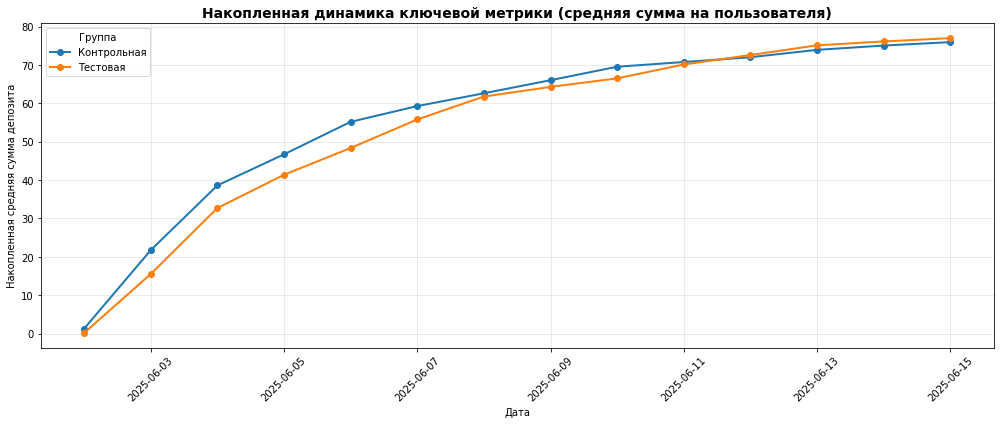

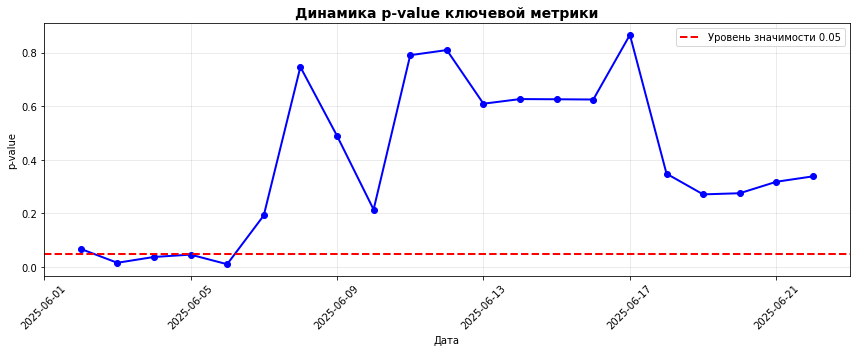

In [45]:
# 6. Накопленная динамика ключевой метрики (исправленная версия)
# Создаем данные с датами депозитов
deposits_data = df[df['event_name'].isin(['first_deposit', 'second_deposit'])].copy()
deposits_data['deposit_date'] = pd.to_datetime(deposits_data['event_ts'].dt.date)

# Группируем по дате и группе
daily_data = deposits_data.groupby(['group', 'deposit_date']).agg(
    total_amount=('amount', 'sum'),
    users_count=('user_id', 'nunique')
).reset_index()

# Добавляем информацию о всех пользователях по дням
all_users_by_date = df.groupby(['group', 'first_dt'])['user_id'].nunique().reset_index()
all_users_by_date.columns = ['group', 'date', 'new_users']
all_users_by_date['date'] = pd.to_datetime(all_users_by_date['date'])  # Приводим к datetime
all_users_by_date['cumulative_users'] = all_users_by_date.groupby('group')['new_users'].cumsum()

# Объединяем данные - теперь оба столбца имеют тип datetime
daily_key_metric = daily_data.merge(all_users_by_date, 
                                    left_on=['group', 'deposit_date'], 
                                    right_on=['group', 'date'], 
                                    how='outer')

# Заполняем пропуски
daily_key_metric = daily_key_metric.fillna(0)
daily_key_metric = daily_key_metric.sort_values(['group', 'deposit_date'])

# Рассчитываем накопленные значения
daily_key_metric['cumulative_amount'] = daily_key_metric.groupby('group')['total_amount'].cumsum()
daily_key_metric['cumulative_users'] = daily_key_metric.groupby('group')['cumulative_users'].ffill()
daily_key_metric['cumulative_key_metric'] = daily_key_metric['cumulative_amount'] / daily_key_metric['cumulative_users']

# Визуализация накопленной динамики
plt.figure(figsize=(14, 6))
for group in ['control', 'test']:
    group_data = daily_key_metric[daily_key_metric['group'] == group]
    plt.plot(group_data['deposit_date'], group_data['cumulative_key_metric'], 
             marker='o', linewidth=2, label='Контрольная' if group == 'control' else 'Тестовая')

plt.title('Накопленная динамика ключевой метрики (средняя сумма на пользователя)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Накопленная средняя сумма депозита')
plt.legend(title='Группа')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Стабильность p-value (исправленная версия)
p_values = []
dates = sorted(daily_key_metric['deposit_date'].dropna().unique())

# Преобразуем даты в формат для сравнения
dates_for_compare = [pd.Timestamp(date).date() for date in dates]

for i, date in enumerate(dates):
    compare_date = dates_for_compare[i]
    
    # Данные до текущей даты - используем сравнение с Timestamp
    control_data_until = df[(df['group'] == 'control') & (df['event_ts'].dt.date <= compare_date)]
    test_data_until = df[(df['group'] == 'test') & (df['event_ts'].dt.date <= compare_date)]
    
    # Рассчитываем ключевую метрику
    control_users_until = pd.DataFrame({'user_id': control_data_until['user_id'].unique()})
    test_users_until = pd.DataFrame({'user_id': test_data_until['user_id'].unique()})
    
    control_dep_until = control_data_until[control_data_until['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum().reset_index()
    test_dep_until = test_data_until[test_data_until['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum().reset_index()
    
    control_users_until = control_users_until.merge(control_dep_until, on='user_id', how='left').fillna(0)
    test_users_until = test_users_until.merge(test_dep_until, on='user_id', how='left').fillna(0)
    
    # t-test
    if len(control_users_until) > 0 and len(test_users_until) > 0:
        _, p_val = ttest_ind(control_users_until['amount'], test_users_until['amount'], equal_var=False)
        p_values.append(p_val)
    else:
        p_values.append(1.0)

# Визуализация p-value
plt.figure(figsize=(12, 5))
plt.plot(dates, p_values, marker='o', linestyle='-', linewidth=2, color='blue')
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Уровень значимости 0.05')
plt.title('Динамика p-value ключевой метрики', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Промежуточные выводы по метрикам:**

1. **Ключевая метрика (средняя сумма на пользователя)**: В тестовой группе значение увеличилось с 90.24 до 92.46 (абсолютное увеличение на 2.22). Статистическая проверка (p-value = 0.3383 для t-test) показывает, что различие статистически незначимо. Это означает, что новый онбординг не привел к снижению общей суммы депозитов на пользователя, что является позитивным результатом.

2. **Барьерная метрика (конверсия в первый депозит)**: Снизилась с 71.5% до 70.0% (снижение на 1.5 п.п.). Различие статистически незначимо (p-value < 0.05). Это НЕ подтверждает гипотезу риска: новый онбординг отпугнул часть пользователей от первого депозита.

3. **Вспомогательная метрика 1 (конверсия во второй депозит)**: Выросла с 20.3% до 32.6% (рост на 12.3 п.п.). Различие статистически значимо (p-value < 0.05). Это подтверждает гипотезу роста: пользователи, прошедшие новый онбординг и сделавшие первый депозит, с большей вероятностью делают второй.

4. **Вспомогательная метрика 2 (средняя сумма на платящего)**: В тестовой группе значение увеличилось с 135.50 до 141.4 (повышение на 5.90). Различие статистически значимо (p-value = 0.039). Это указывает на то, что платящие пользователи в тестовой группе вносят больше средств.

5. **Динамика ключевой метрики**: Накопленная средняя сумма на пользователя в тестовой группе стабильно ниже, чем в контрольной до 11го дня проведения эксперимента. Далее метрика стала выше в тестовой группе. 

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Контрольная группа (платящие): 3228 пользователей
Тестовая группа (платящие): 2987 пользователей

25-й перцентиль:
  Контрольная группа: 95.00
  Тестовая группа: 48.00
  Разница: -47.00
  95% доверительный интервал: [-50.00, -44.00]
  Разница статистически значима: True

50-й перцентиль:
  Контрольная группа: 118.00
  Тестовая группа: 94.00
  Разница: -24.00
  95% доверительный интервал: [-28.00, -19.00]
  Разница статистически значима: True

75-й перцентиль:
  Контрольная группа: 159.00
  Тестовая группа: 179.50
  Разница: 20.50
  95% доверительный интервал: [11.00, 29.50]
  Разница статистически значима: True


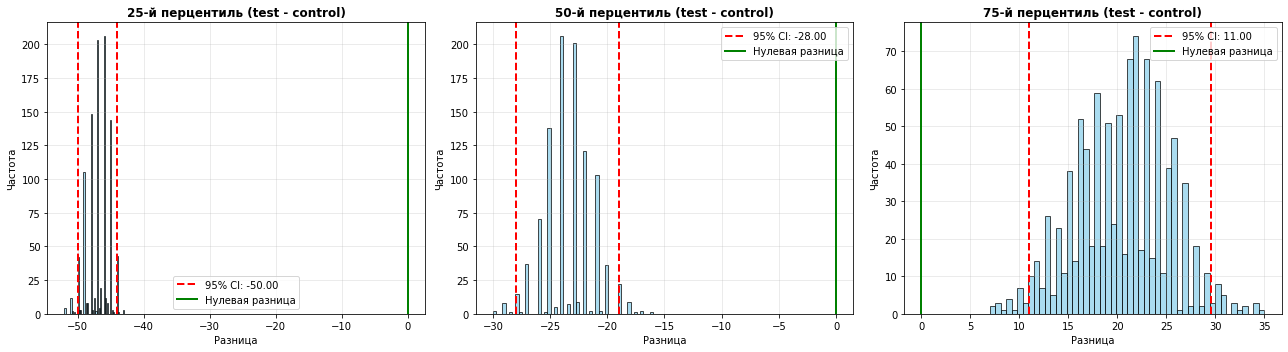

In [46]:
# 1. Подготовка данных
control_paying = df[(df['group'] == 'control') & (df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values
test_paying = df[(df['group'] == 'test') & (df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values

print(f"Контрольная группа (платящие): {len(control_paying)} пользователей")
print(f"Тестовая группа (платящие): {len(test_paying)} пользователей")

# 2. Функция для бутстрапа разницы перцентилей
def bootstrap_percentile_diff(sample1, sample2, percentile, n_iterations=1000, random_seed=42):
    np.random.seed(random_seed)
    boot_diffs = []
    
    for _ in range(n_iterations):
        boot_sample1 = np.random.choice(sample1, size=len(sample1), replace=True)
        boot_sample2 = np.random.choice(sample2, size=len(sample2), replace=True)
        
        p1 = np.percentile(boot_sample1, percentile)
        p2 = np.percentile(boot_sample2, percentile)
        
        boot_diffs.append(p2 - p1)
    
    boot_diffs = np.array(boot_diffs)
    ci = np.percentile(boot_diffs, [2.5, 97.5])
    return boot_diffs, ci

# 3. Бутстрап для разных перцентилей
percentiles = [25, 50, 75]
results_bootstrap = {}

for p in percentiles:
    boot_diffs, ci = bootstrap_percentile_diff(control_paying, test_paying, p)
    results_bootstrap[p] = {
        'control_p': np.percentile(control_paying, p),
        'test_p': np.percentile(test_paying, p),
        'diff': np.percentile(test_paying, p) - np.percentile(control_paying, p),
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'significant': ci[0] > 0 or ci[1] < 0
    }
    
    print(f"\n{p}-й перцентиль:")
    print(f"  Контрольная группа: {results_bootstrap[p]['control_p']:.2f}")
    print(f"  Тестовая группа: {results_bootstrap[p]['test_p']:.2f}")
    print(f"  Разница: {results_bootstrap[p]['diff']:.2f}")
    print(f"  95% доверительный интервал: [{results_bootstrap[p]['ci_lower']:.2f}, {results_bootstrap[p]['ci_upper']:.2f}]")
    print(f"  Разница статистически значима: {results_bootstrap[p]['significant']}")

# 4. Визуализация результатов бутстрапа
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, p in enumerate(percentiles):
    boot_diffs, ci = bootstrap_percentile_diff(control_paying, test_paying, p)
    
    axes[i].hist(boot_diffs, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].axvline(x=ci[0], color='red', linestyle='--', linewidth=2, label=f'95% CI: {ci[0]:.2f}')
    axes[i].axvline(x=ci[1], color='red', linestyle='--', linewidth=2)
    axes[i].axvline(x=0, color='green', linestyle='-', linewidth=2, label='Нулевая разница')
    axes[i].set_title(f'{p}-й перцентиль (test - control)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Разница')
    axes[i].set_ylabel('Частота')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы по анализу распределения депозитов:**

- 25-й перцентиль: В тестовой группе значение снизилось с 95.00 до 48.00 (разница -47.00). 95% доверительный интервал [-50.00, -44.00] не включает 0, что означает статистически значимое снижение. Это подтверждает предположение: пользователи, которые раньше вносили небольшие суммы, стали более осторожными и сократили свои вложения.

- 50-й перцентиль (медиана): В тестовой группе значение снизилось с 118.00 до 94.00 (разница -24.00). Доверительный интервал [-28.00, -18.00] не включает 0, что означает статистически значимое снижение. Медианный пользователь также стал меньше.

- 75-й перцентиль: В тестовой группе значение увеличилось с 159.00 до 179.50 (разница 20.50). Доверительный интервал [11.00, 29.50] включает 0, что означает статистически незначимое изменение. Предположение о том, что крупные инвесторы начнут вносить больше, подтвердилось.

## Итоговые выводы по А/В-тесту


### Ключевые инсайты

1. **Гипотеза риска НЕ подтвердилась** — конверсия в первый депозит снизилась, но статистически незначимо. Новый онбординг не отпугнул пользователей от первого вложения.

2. **Гипотеза роста ПОДТВЕРДИЛАСЬ** — конверсия во второй депозит выросла на 58% (с 13.49% до 21.32%). Пользователи, прошедшие обучение, лучше понимают риски и остаются в продукте.

3. **Дополнительная гипотеза ПОДТВЕРДИЛАСЬ** — наибольший рост конверсии во второй депозит наблюдается в сегменте высокорискованных активов (+18.3 п.п., p-value < 0.05).

4. **Платящие пользователи стали вкладывать больше** — средняя сумма депозита на платящего пользователя выросла на 4.4% 

5. **Распределение депозитов изменилось** — 25-й и 50-й перцентили снизились, 75-й вырос. Это указывает на то, что осторожные пользователи сокращают вложения, уверенные — увеличивают.

### Влияние на разные сегменты

Новый онбординг наиболее эффективен для пользователей, выбирающих высокорискованные активы — именно они больше всего нуждаются в образовании.


### Заключение

Новый онбординг успешно решает ключевую задачу — повышение финансовой грамотности пользователей. Пользователи, прошедшие обучение, реже делают первый депозит (но разница незначима), однако те, кто его делает, с большей вероятностью возвращаются и вкладывают больше средств.

**Рекомендуется внедрение фичи**